# Exploracion del dataset de Amazon

Carga del archivo CSV en un DataFrame de pandas y vista inicial de su contenido.

In [1]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError('No se encontro data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)
print(f'Dataset cargado desde: {ruta_dataset.resolve()}')
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
df.head(10)

Dataset cargado desde: /Users/mariajosedelgadofalcon/Desktop/AI_DA_MariaJoseDelgadoFalcon/data/Amazon_Sales.csv
Dimensiones: 128,975 filas x 22 columnas


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B
0,0,405-8078784-5731545,22/04/30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,Not Shipped,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,No Promotion,False
1,1,171-9198151-1101146,22/04/30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,False
2,2,404-0687676-7273146,22/04/30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True
3,3,403-9615377-8133951,22/04/30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,Not Shipped,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,No Promotion,False
4,4,407-1069790-7240320,22/04/30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,No Promotion,False
5,5,404-1490984-4578765,22/04/30,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,...,Shipped,1,INR,824.00,GHAZIABAD,UTTAR PRADESH,201102,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False
6,6,408-5748499-6859555,22/04/30,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,...,Shipped,1,INR,653.00,CHANDIGARH,CHANDIGARH,160036,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False
7,7,406-7807733-3785945,22/04/30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3405,JNE3405-KR-S,kurta,...,Shipped,1,INR,399.00,HYDERABAD,TELANGANA,500032,IN,Amazon PLCC Free-Financing Universal Merchant ...,False
8,8,407-5443024-5233168,22/04/30,Cancelled,Amazon,Amazon.in,Expedited,SET200,SET200-KR-NP-A-XXXL,Set,...,Cancelled,0,INR,0.00,HYDERABAD,TELANGANA,500008,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False
9,9,402-4393761-0311520,22/04/30,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,...,Shipped,1,INR,363.00,CHENNAI,TAMIL NADU,600041,IN,No Promotion,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      128975 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            128975 non-null  object 
 15  Amount              128975 non-nul

In [3]:
df["SKU"]

0          SET389-KR-NP-S
1         JNE3781-KR-XXXL
2           JNE3371-KR-XL
3              J0341-DR-L
4         JNE3671-TU-XXXL
               ...       
128970      JNE3697-KR-XL
128971     SET401-KR-NP-M
128972       J0157-DR-XXL
128973       J0012-SKD-XS
128974        J0003-SET-S
Name: SKU, Length: 128975, dtype: object

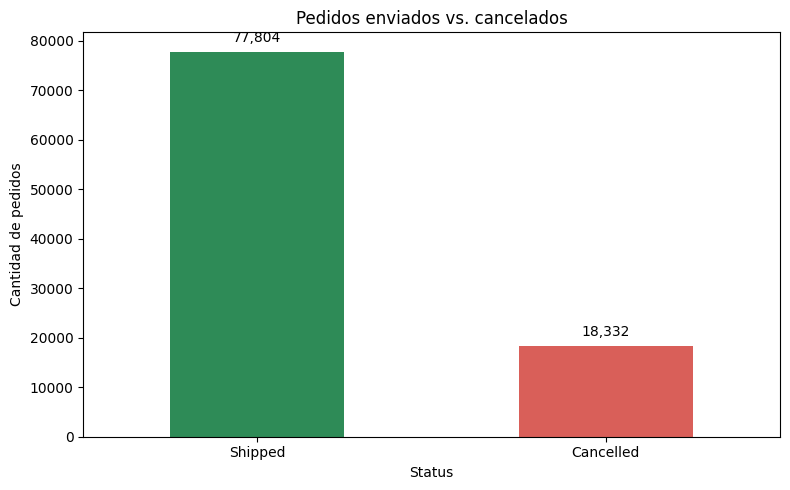

In [4]:
import matplotlib.pyplot as plt

conteo_status = df['Status'].value_counts().reindex(['Shipped', 'Cancelled']).fillna(0)

ax = conteo_status.plot(kind='bar', color=['#2E8B57', '#D95F59'], figsize=(8, 5))
ax.set_title('Pedidos enviados vs. cancelados')
ax.set_xlabel('Status')
ax.set_ylabel('Cantidad de pedidos')
ax.set_xticklabels(['Shipped', 'Cancelled'], rotation=0)

for barra, cantidad in zip(ax.patches, conteo_status):
    ax.annotate(f'{int(cantidad):,}',
                (barra.get_x() + barra.get_width() / 2, barra.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

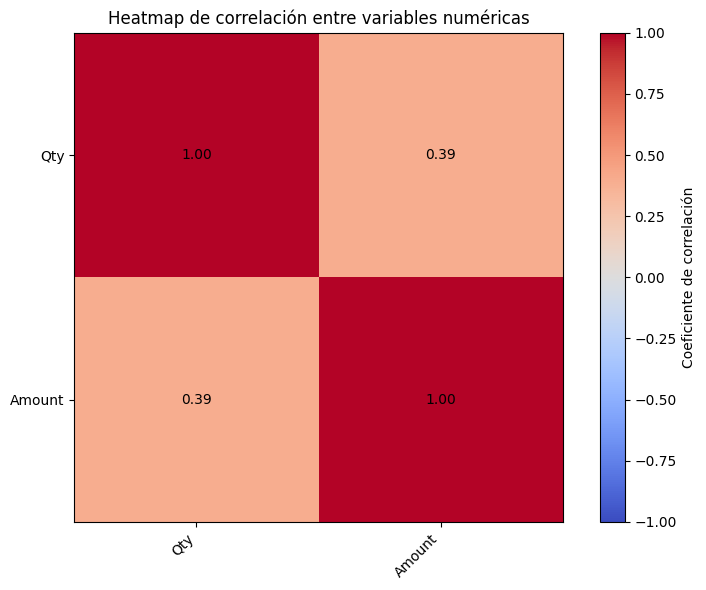

In [5]:
import matplotlib.pyplot as plt

columnas_numericas = df.select_dtypes(include='number').columns.tolist()
columnas_excluir = ['index', 'ship-postal-code']
columnas_correlacion = [
    columna for columna in columnas_numericas
    if columna not in columnas_excluir
]

matriz_correlacion = df[columnas_correlacion].corr()

fig, ax = plt.subplots(figsize=(8, 6))
imagen = ax.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(imagen, ax=ax, label='Coeficiente de correlación')

ax.set_xticks(range(len(matriz_correlacion.columns)))
ax.set_yticks(range(len(matriz_correlacion.index)))
ax.set_xticklabels(matriz_correlacion.columns, rotation=45, ha='right')
ax.set_yticklabels(matriz_correlacion.index)
ax.set_title('Heatmap de correlación entre variables numéricas')

for fila in range(matriz_correlacion.shape[0]):
    for columna in range(matriz_correlacion.shape[1]):
        ax.text(columna, fila, f'{matriz_correlacion.iloc[fila, columna]:.2f}',
                ha='center', va='center', color='black')

plt.tight_layout()
plt.show()